<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 40px 0 32px; margin-bottom: 8px;">
 <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:2px; margin:0 0 10px;">Lead University · Minería de Datos I</p>
 <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:2.3em; color:#000; margin:0 0 10px; font-weight:700; letter-spacing:0.3px;">Análisis de Correspondencia Múltiple (ACM)</h1>
 <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#444; margin:0; font-style:italic;">Aplicación de la técnica ACM sobre dos conjuntos de datos categóricos: vuelos comerciales y campañas de marketing bancario</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 28px 32px; margin: 8px 0 32px; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:2px;">Índice</span>
 <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.25em; color:#000; margin:6px 0 16px; font-weight:700;">Contenido del Notebook</h2>
 <table style="width:100%; border-collapse:collapse; font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em;">
  <tr>
   <td style="padding:6px 0; color:#b85300; font-weight:600; width:28px;">1.</td>
   <td style="padding:6px 0;"><a href="#marco-teorico" style="color:#000; text-decoration:none; font-weight:600;">Marco Teórico</a><br>
   <span style="font-size:0.85em; color:#777;">Fundamentos del Análisis de Correspondencia Múltiple</span></td>
  </tr>
  <tr>
   <td style="padding:6px 0; color:#b85300; font-weight:600;">2.</td>
   <td style="padding:6px 0;"><a href="#fase1-d1" style="color:#000; text-decoration:none; font-weight:600;">Dataset 1 — Vuelos Comerciales</a><br>
   <span style="font-size:0.85em; color:#777;">
    <a href="#fase1-d1" style="color:#777; text-decoration:none;">Preparación de Datos</a> ·
    <a href="#fase2-d1" style="color:#777; text-decoration:none;">Aplicación del ACM</a> ·
    <a href="#fase3-d1" style="color:#777; text-decoration:none;">Interpretación del Espacio Factorial</a>
   </span></td>
  </tr>
  <tr>
   <td style="padding:6px 0; color:#b85300; font-weight:600;">3.</td>
   <td style="padding:6px 0;"><a href="#fase1-d2" style="color:#000; text-decoration:none; font-weight:600;">Dataset 2 — Banking Dataset</a><br>
   <span style="font-size:0.85em; color:#777;">
    <a href="#fase1-d2" style="color:#777; text-decoration:none;">Preparación de Datos</a> ·
    <a href="#fase2-d2" style="color:#777; text-decoration:none;">Aplicación del ACM</a> ·
    <a href="#fase3-d2" style="color:#777; text-decoration:none;">Interpretación del Espacio Factorial</a>
   </span></td>
  </tr>
  <tr>
   <td style="padding:6px 0; color:#b85300; font-weight:600;">4.</td>
   <td style="padding:6px 0;"><a href="#fase4-comparacion" style="color:#000; text-decoration:none; font-weight:600;">Comparación y Discusión</a><br>
   <span style="font-size:0.85em; color:#777;">Dataset 1 &amp; Dataset 2 · ACM vs. PCA · Perspectiva de negocio</span></td>
  </tr>
 </table>
</div>

<div style="margin: 32px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Configuración</span>
 <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Librerías</h2>
</div>

In [1]:
%matplotlib inline
import pandas as pd
import importlib
import scripts.Dataset_2 as Baking_Dataset
importlib.reload(Baking_Dataset)

import scripts.Dataset_1 as datos_vuelos_comerciales
importlib.reload(datos_vuelos_comerciales)

from scripts.Dataset_1 import ACM as ACM_Vuelos
from scripts.Dataset_2 import ACM as ACM_Baking

import warnings
warnings.filterwarnings('ignore')

df1 = pd.read_csv("data/datos_vuelos_comerciales.csv", sep=',')

df2 = pd.read_csv("data/Banking_Dataset.csv", sep=';')
print(df2.columns.tolist())
print(df2.shape)

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
(45211, 17)


<div id="marco-teorico" style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Marco Teórico</span>
 <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Fundamentos del Análisis de Correspondencia Múltiple</h1>
 <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Definición de la técnica, objetivo y justificación de su uso para los conjuntos de datos analizados</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Marco Teórico</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">¿Qué es el ACM?</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El Análisis de Correspondencia Múltiple (ACM) es una técnica de reducción de dimensionalidad orientada al estudio de variables categóricas. Su propósito es representar las relaciones entre categorías e individuos en un espacio de menor dimensión, facilitando la identificación de patrones y asociaciones que resultarían difíciles de detectar directamente en la tabla de datos original.</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Marco Teórico</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">¿Cuál es su objetivo?</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El objetivo del ACM es reducir la dimensionalidad del conjunto de datos conservando la mayor proporción posible de inercia (varianza explicada) en los primeros componentes. De esta manera se simplifica la interpretación de las relaciones entre categorías sin perder información relevante.</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Marco Teórico</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">¿Por qué es apropiado para estos datasets?</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El ACM resulta apropiado porque ambos conjuntos de datos están compuestos principalmente por variables categóricas, no numéricas continuas. Mientras que técnicas como PCA están diseñadas para variables cuantitativas, el ACM es la herramienta adecuada para datos cualitativos. Adicionalmente, permite identificar grupos de individuos con perfiles similares y categorías que tienden a co-ocurrir dentro del conjunto de datos.</p>
</div>

<div id="fase1-d1" style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 1 | Dataset 1</span>
 <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Datos de Vuelos Comerciales | Preparación de Datos</h1>
 <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Manejo de valores faltantes, eliminación de registros inconsistentes y conversión de variables necesarias</p>
</div>

In [3]:
print(f'filas: {len(df1):,} | Columnas: {df1.shape[1]}')
df1.head()

filas: 300,153 | Columnas: 12


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [2]:
cat_cols = df1.select_dtypes(include=['object']).columns
df1_cat = df1[cat_cols]

print('info():')
df1.info()

info():
<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


<div id="fase2-d1" style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 2 — Aplicación del ACM</span>
 <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Scree Plot</h2>
</div>

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.240         6.01%                      6.01%
1              0.197         4.94%                     10.95%
2              0.192         4.79%                     15.73%
3              0.187         4.69%                     20.42%
4              0.183         4.56%                     24.98%
5              0.173         4.33%                     29.31%
6              0.171         4.28%                     33.59%
7              0.164         4.09%                     37.68%
8              0.161         4.03%                     41.71%
9              0.160         4.01%                     45.71%


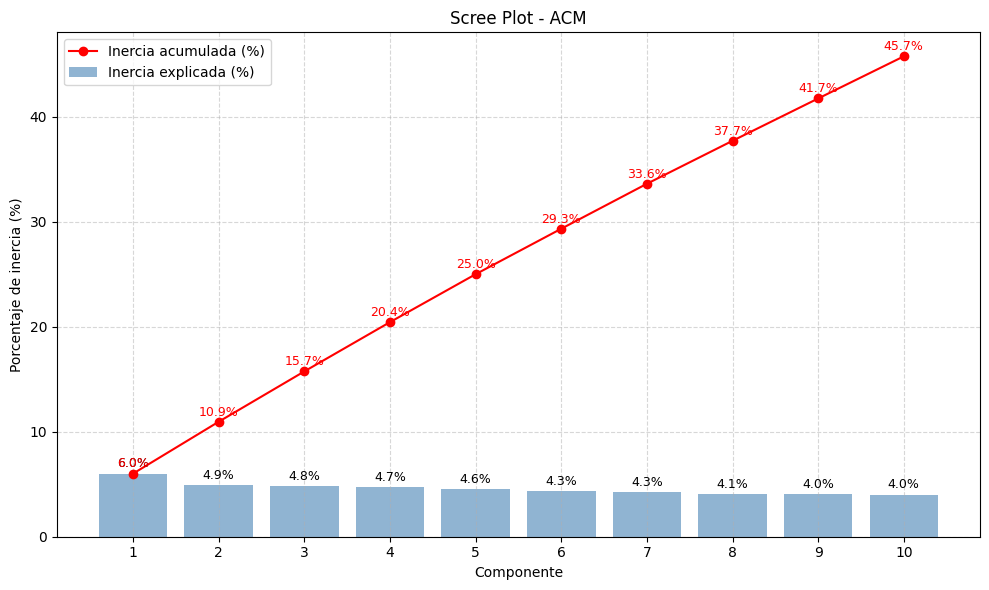

In [4]:
cat_cols = ['airline', 'source_city', 'departure_time', 'stops', 
            'arrival_time', 'destination_city', 'class']
df1_cat = df1[cat_cols].astype(str) 

acm1 = ACM_Vuelos(df1_cat, n_components=10, sample_size=3000)
print(acm1.acm_fit.eigenvalues_summary) #datos
acm1.scree_plot()

<div id="fase3-d1" style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 3 — Interpretación del Espacio Factorial</span>
 <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Biplot</h2>
</div>

In [5]:
acm1.biplot()

alt.LayerChart(...)

<div id="fase1-d2" style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 1 | Dataset 2</span>
 <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Banking Dataset | Preparación de Datos</h1>
 <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Manejo de valores faltantes, eliminación de registros inconsistentes y conversión de variables necesarias</p>
</div>

In [6]:
print(f'filas: {len(df2):,} | Columnas: {df2.shape[1]}')
df2.head()

filas: 45,211 | Columnas: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
cat_cols = df2.select_dtypes(include=['object']).columns
df2_cat = df2[cat_cols]

print('info():')
df2.info()

info():
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [8]:
df2.select_dtypes(include=['object', 'category']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')

<div id="fase2-d2" style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 2 — Aplicación del ACM</span>
 <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Scree Plot</h2>
</div>

10
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.230         6.39%                      6.39%
1              0.175         4.87%                     11.25%
2              0.157         4.37%                     15.62%
3              0.153         4.25%                     19.87%
4              0.146         4.05%                     23.92%
5              0.127         3.54%                     27.46%
6              0.126         3.50%                     30.96%
7              0.118         3.28%                     34.24%
8              0.114         3.18%                     37.42%
9              0.112         3.11%                     40.53%


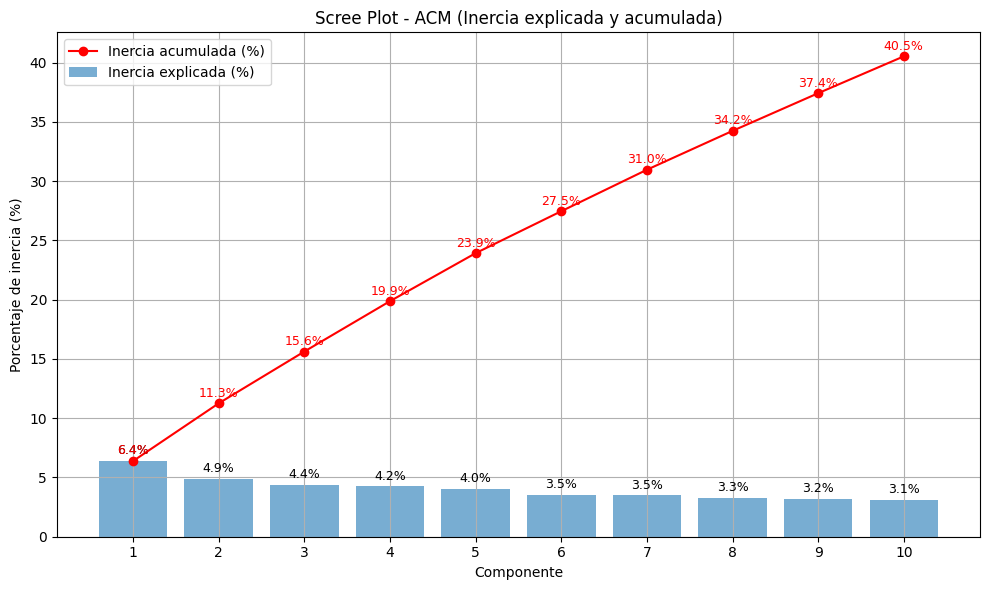

In [11]:
cat_cols = ['job', 'marital', 'education', 'default', 
            'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

df2_cat = df2[cat_cols].astype(str)

acm2 = ACM_Baking(df2_cat, n_components=len(cat_cols))
print(len(cat_cols))
print(acm2.acm_fit.eigenvalues_summary) #datos
acm2.scree_plot()

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 2 — Aplicación del ACM</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">¿Cuántos componentes considera adecuados?</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Dado que la distribución de la inercia entre componentes es bastante plana, una justificación razonable es conservar los primeros dos o tres componentes. Aunque la inercia acumulada es baja (entre 15% y 19%), estos componentes capturan la mayor proporción relativa respecto al resto y permiten una visualización interpretable en un biplot bidimensional. Es habitual que el ACM presente inercias acumuladas bajas, ya que cada variable categórica aporta una dispersión considerable al espacio factorial.</p>
</div>

<div id="fase3-d2" style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 3 — Interpretación del Espacio Factorial</span>
 <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Biplot</h2>
</div>

In [12]:
acm2.biplot()

alt.LayerChart(...)

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 3 — Interpretación del Espacio Factorial</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">Interpretación general</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Las categorías que aparecen cercanas entre sí en el biplot tienden a co-ocurrir en los mismos individuos. Por ejemplo, los individuos jubilados (<code>job__retired</code>) tienden a presentar <code>education__unknown</code> y <code>housing__no</code>, mientras que los individuos solteros (<code>marital__single</code>) se asocian más con <code>month__jan</code> y <code>job__technician</code>.</p> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">Componentes principales</p> <ul style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7; padding-left:20px;">
  <li style="margin-bottom:6px;">Componente 0 (6.39%): separa perfiles laborales y de vivienda.</li>
  <li style="margin-bottom:6px;">Componente 1 (4.87%): separa por estado civil y temporalidad (meses).</li>
 </ul>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 3 — Interpretación del Espacio Factorial</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">¿Qué categorías aparecen cercanas?</h3>
 <ul style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7; padding-left:20px;">
  <li style="margin-bottom:6px;"><strong>Zona superior derecha:</strong> <code>job__retired</code>, <code>education__unknown</code> y <code>housing__no</code> aparecen próximas, lo que sugiere que estas categorías comparten un perfil similar de individuos.</li>
  <li style="margin-bottom:6px;"><strong>Zona central:</strong> <code>job__self-employed</code>, <code>loan__no</code>, <code>marital__married</code> y <code>outcome__unknown</code> se agrupan juntas, indicando un perfil de personas casadas, independientes y sin préstamo activo.</li>
  <li style="margin-bottom:6px;"><strong>Zona inferior:</strong> por un lado <code>job__admin</code>, <code>job__services</code> y <code>housing__yes</code>, y por otro <code>marital__single</code>, <code>job__technician</code> y <code>month__jan</code>, forman subgrupos diferenciados.</li>
 </ul> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Qué asociaciones interesantes se encuentran?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Los individuos jubilados tienden a asociarse con <code>education__unknown</code> y <code>housing__no</code>, lo que sugiere un perfil de mayor edad sin vivienda financiada. Las personas solteras (<code>marital__single</code>) se asocian con <code>job__technician</code> y los meses de enero y noviembre, posiblemente relacionado con campañas de contacto en esos períodos. Por su parte, <code>poutcome__failure</code> y <code>poutcome__success</code> aparecen separados del centro, lo que indica que el resultado de campañas anteriores diferencia claramente los perfiles.</p> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Existen grupos o patrones visibles?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Sí. El biplot muestra una dispersión amplia de los individuos (puntos naranjas) sin clusters extremadamente definidos, lo cual es consistente con la baja inercia explicada por los dos primeros componentes (6.39% y 4.87%, totalizando apenas 11.26%). Esto indica que ningún par de componentes captura por sí solo una estructura dominante; sin embargo, sí se distinguen perfiles en los extremos: jubilados y personas con resultados de campaña previos se separan notablemente del grupo central, mientras que la mayoría de los individuos comparte características similares y se concentra en el centro del biplot.</p>
</div>

<div id="fase4-comparacion" style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
 <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 4 — Comparación y Discusión</span>
 <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Dataset 1 &amp; Dataset 2</h2>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 4 — Comparación y Discusión</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">Comparación de los resultados obtenidos en ambos datasets</h3>
 <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Cuál dataset presentó asociaciones más claras?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El dataset de banca (Dataset 2) presentó asociaciones más claras y fáciles de delimitar entre categorías, a pesar de su baja inercia acumulada.</p> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Cuál mostró mayor dispersión?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El Dataset 2 mostró mayor dispersión entre categorías. El Dataset 1 (vuelos comerciales) concentraba la información en un agrupamiento más compacto, lo que dificultaba distinguir subgrupos diferenciados.</p> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Cuál fue más fácil de interpretar?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">El Dataset 2 fue más fácil de interpretar, ya que sus agrupaciones por perfil laboral, estado civil y resultado de campañas previas resultaron más intuitivas de explicar en términos de negocio.</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 4 — Comparación y Discusión</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">Comparación entre ACM y PCA</h3>
 <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;"><strong>Diferencias principales:</strong> el ACM trabaja sobre variables categóricas mediante tablas de contingencia e inercia, mientras que el PCA opera sobre variables numéricas continuas a partir de matrices de varianza-covarianza.</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;"><strong>Tipo de variables utilizadas:</strong> el ACM requiere variables cualitativas (categóricas), mientras que el PCA requiere variables cuantitativas continuas.</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;"><strong>Casos de uso:</strong> el ACM es apropiado para encuestas, segmentación de clientes y análisis de variables categóricas en general; el PCA es apropiado para reducción de dimensionalidad en datos numéricos, como mediciones físicas, indicadores financieros o variables continuas de sensores.</p>
</div>

<div style="border: 1px solid #e8d9c5; border-radius: 4px; padding: 24px 28px; margin: 20px 0; background-color: #fffaf5;">
 <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 4 — Comparación y Discusión</span>
 <h3 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.15em; color:#000; margin:6px 0 12px; font-weight:600;">Perspectiva de negocio</h3>
 <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Cómo podría utilizarse este análisis en una aerolínea?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Permitiría identificar combinaciones frecuentes entre aerolínea, ciudad de origen, horario y clase de vuelo, lo cual es útil para diseñar estrategias de precios diferenciados, optimizar rutas y personalizar ofertas según el perfil de los pasajeros.</p> <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.0em; color:#b85300; margin:18px 0 6px; font-weight:600;">¿Cómo podría utilizarse en marketing bancario?</p> <p style="font-size:0.94em; color:#333333; margin:0 0 12px; line-height:1.7;">Permitiría segmentar clientes según perfil laboral, estado civil y resultado de campañas anteriores, facilitando el diseño de campañas de marketing dirigidas a los segmentos con mayor probabilidad de respuesta positiva.</p>
</div>